# Customer Behavior Analysis: Building a Churn Prediction System

## Project Goals

- Analyze customer behavior data including communication, product preferences, purchasing patterns, and online activity
- Build a model to predict customer activity decline based on historical data
- Identify key factors influencing customer activity using interpretable ML methods like SHAP
- Segment customers based on their behavior, profitability, and activity levels
- Develop personalized recommendations for customer segments to increase engagement:
    - Design targeted marketing strategies
    - Provide actionable insights for retention campaigns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik.report import plot_correlation_matrix
from phik import resources
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder, 
    StandardScaler, 
    MinMaxScaler,
    RobustScaler
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer 
from scipy import stats as st
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score
import shap
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier

## Data Description

**market_file.csv** - Customer behavior on the website, communication history, and product preferences:
- `id` — Customer ID in the database
- `buying_activity` — Calculated activity class (target): "declined" or "stable"
- `service_type` — Service tier: "premium" or "standard"
- `messages_allowed` — Whether customer allows marketing messages (yes/no)
- `marketing_6_mon_avg` — Average monthly marketing communications over 6 months
- `marketing_curr_mon` — Marketing communications this month
- `duration` — Customer relationship duration (days)
- `promo_purchases` — Share of promotional purchases
- `favourite_cat` — Most purchased category
- `session_cat_avg` — Average categories viewed per session
- `card_items_quarter_avg` — Average unpaid cart items per quarter
- `downtime_count` — Number of service outages experienced
- `session_pages_avg` — Average pages viewed per session

**market_money.csv** - Revenue data by period:
- `id` — Customer ID
- `period` — Time period (previous_month, current_month, etc.)
- `revenue` — Revenue from customer

**market_time.csv** - Time spent on site by period:
- `id` — Customer ID
- `period` — Time period
- `mins` — Minutes spent on site

**money.csv** - Profitability data:
- `id` — Customer ID
- `income` — Average profit per customer over 3 months

### Loading Data

In [2]:
market_file_df = pd.read_csv('../../datasets/market_file.csv')
market_money_df = pd.read_csv('../../datasets/market_money.csv')
market_time_df = pd.read_csv('../../datasets/market_time.csv')
money_df = pd.read_csv('../../datasets/money.csv', sep = ';', decimal = ',')

Let's preview each dataset to understand the data structure.

In [3]:
market_file_df.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [4]:
market_money_df.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [5]:
market_time_df.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [6]:
money_df.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


### Data Overview

Let's examine the general information about each dataset.

In [7]:
market_file_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

For `market_file_df`:
- No missing values
- Data types are correct

In [8]:
market_money_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


For `market_money_df`:
- No missing values
- Data types are correct

In [9]:
market_time_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


For `market_time_df`:
- No missing values
- Data types are correct

In [10]:
money_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


For `money_df`:
- No missing values
- Data types are correct

### Summary

All data files loaded successfully. Data formats match the documentation. No missing values found, and data types are correct. Proceeding to data preprocessing.

## Data Preprocessing

### Column Renaming

For easier data manipulation, we'll rename all columns to English using snake_case convention.

Column mappings for `market_file_df`:
- `Покупательская активность` → `buying_activity`
- `Тип сервиса` → `service_type`
- `Разрешить сообщать` → `messages_allowed`
- `Маркет_актив_6_мес` → `marketing_6_mon_avg`
- `Маркет_актив_тек_мес` → `marketing_curr_mon`
- `Длительность` → `duration`
- `Акционные_покупки` → `promo_purchases`
- `Популярная_категория` → `favourite_cat`
- `Средний_просмотр_категорий_за_визит` → `session_cat_avg`
- `Неоплаченные_продукты_штук_квартал` → `card_items_quorter_avg`
- `Ошибка_сервиса` → `downtime_count`
- `Страниц_за_визит` → `session_pages_avg`

In [11]:
# Rename columns in market_file_df
market_file_df = market_file_df.rename(columns = {
    'Покупательская активность': 'buying_activity',
    'Тип сервиса': 'service_type',
    'Разрешить сообщать': 'messages_allowed',
    'Маркет_актив_6_мес': 'marketing_6_mon_avg',
    'Маркет_актив_тек_мес': 'marketing_curr_mon',
    'Длительность': 'duration',
    'Акционные_покупки': 'promo_purchases',
    'Популярная_категория': 'favourite_cat',
    'Средний_просмотр_категорий_за_визит': 'session_cat_avg',
    'Неоплаченные_продукты_штук_квартал': 'card_items_quorter_avg',
    'Ошибка_сервиса': 'downtime_count',
    'Страниц_за_визит': 'session_pages_avg'
})
market_file_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1300 non-null   int64  
 1   buying_activity         1300 non-null   object 
 2   service_type            1300 non-null   object 
 3   messages_allowed        1300 non-null   object 
 4   marketing_6_mon_avg     1300 non-null   float64
 5   marketing_curr_mon      1300 non-null   int64  
 6   duration                1300 non-null   int64  
 7   promo_purchases         1300 non-null   float64
 8   favourite_cat           1300 non-null   object 
 9   session_cat_avg         1300 non-null   int64  
 10  card_items_quorter_avg  1300 non-null   int64  
 11  downtime_count          1300 non-null   int64  
 12  session_pages_avg       1300 non-null   int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 132.2+ KB


Column mappings for `market_money_df`:
- `Период` → `period`
- `Выручка` → `revenue`

In [12]:
# Rename columns in market_money_df
market_money_df = market_money_df.rename(columns = {
    'Период': 'period',
    'Выручка': 'revenue'})
market_money_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   period   3900 non-null   object 
 2   revenue  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


Column mappings for `market_time_df`:
- `Период` → `period`
- `минут` → `mins`

In [13]:
# Rename columns in market_time_df
market_time_df = market_time_df.rename(columns = {
    'Период': 'period',
    'минут': 'mins'})
market_time_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   period  2600 non-null   object
 2   mins    2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


Column mappings for `money_df`:
- `Прибыль` → `income`

In [14]:
# Rename columns in money_df
money_df = money_df.rename(columns = {'Прибыль': 'income'})
money_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      1300 non-null   int64  
 1   income  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


### Categorical Value Preprocessing

Let's examine the categories in each categorical column. Before working with them, we'll standardize all values: remove extra spaces and convert to lowercase.

In [15]:
# List categorical columns in market_file_df
market_file_df_cat = ['buying_activity', 'service_type', 'messages_allowed', 'favourite_cat']

# Strip whitespace and convert to lowercase
for cat_columns in market_file_df_cat:
    market_file_df[cat_columns] = market_file_df[cat_columns].str.strip().str.lower()

# Same for period column in other dataframes
market_money_df['period'] = market_money_df['period'].str.strip().str.lower()
market_time_df['period'] = market_time_df['period'].str.strip().str.lower()

In [16]:
# Check customer buying activity distribution
market_file_df['buying_activity'].value_counts()

buying_activity
прежний уровень    802
снизилась          498
Name: count, dtype: int64

There are exactly two categories as expected. **Class imbalance detected**: customers with "stable" activity outnumber those with "declined" activity almost 2:1.

In [17]:
# Check service types
market_file_df['service_type'].value_counts()

service_type
стандарт     914
премиум      376
стандартт     10
Name: count, dtype: int64

Found a typo in 10 rows with the value . Fixing these incorrect values.

In [18]:
# Fix typo in service_type
market_file_df['service_type'] = market_file_df['service_type'].replace({'стандартт': 'стандарт'})
# Verify
market_file_df['service_type'].value_counts()

service_type
стандарт    924
премиум     376
Name: count, dtype: int64

In [19]:
# Check messages_allowed values
market_file_df['messages_allowed'].value_counts()

messages_allowed
да     962
нет    338
Name: count, dtype: int64

In [20]:
# Check customer favorite categories
market_file_df['favourite_cat'].value_counts()

favourite_cat
товары для детей                        330
домашний текстиль                       251
косметика и аксесуары                   223
техника для красоты и здоровья          184
мелкая бытовая техника и электроника    174
кухонная посуда                         138
Name: count, dtype: int64

Customer favorite categories look correct and require no fixes.

In [21]:
market_money_df['period'].value_counts()

period
препредыдущий_месяц    1300
текущий_месяц          1300
предыдущий_месяц       1300
Name: count, dtype: int64

Three revenue periods are represented in the dataset. No corrections needed.

In [22]:
market_time_df['period'].value_counts()

period
текущий_месяц       1300
предыдцщий_месяц    1300
Name: count, dtype: int64

Found a typo in the time periods column with . Fixing it.

In [23]:
# Fix typo in period column
market_time_df['period'] = market_time_df['period'].replace({'предыдцщий_месяц': 'предыдущий_месяц'})
# Verify
market_time_df['period'].value_counts()

period
текущий_месяц       1300
предыдущий_месяц    1300
Name: count, dtype: int64

All categorical values have been processed and errors fixed. Moving on to duplicate checking.

### Duplicate Check

In [24]:
# Check for duplicates in market_file_df
market_file_df.duplicated().sum()

0

In [25]:
# Check for duplicates in market_money_df
market_money_df.duplicated().sum()

0

In [26]:
# Check for duplicates in market_time_df
market_time_df.duplicated().sum()

0

In [27]:
# Check for duplicates in money_df
money_df.duplicated().sum()

0

No explicit duplicates found in the data. Proceeding to the next step.

### Data Preprocessing Summary

During preprocessing, we completed the following steps:

1. **Column Renaming**: All column names converted to English snake_case for easier data manipulation.
2. **Categorical Value Processing**:
    - Standardized all categorical values: removed extra spaces and applied lowercase
    - Fixed typos in categorical columns like  and 
3. **Missing Values Check**: Confirmed no missing values exist in the dataset.

## Exploratory Data Analysis (EDA)

### Numerical Features Analysis

#### Distribution Analysis: 

In [28]:
# Descriptive statistics for numerical features
numeric_features = ['marketing_6_mon_avg', 'marketing_curr_mon', 'duration', 'promo_purchases',
                    'session_cat_avg', 'card_items_quorter_avg', 'downtime_count', 'session_pages_avg']

market_file_df[numeric_features].describe()

,marketing_6_mon_avg,marketing_curr_mon,duration,promo_purchases,session_cat_avg,card_items_quorter_avg,downtime_count,session_pages_avg
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


Let's visualize the distribution of numerical features by target variable (`buying_activity`).

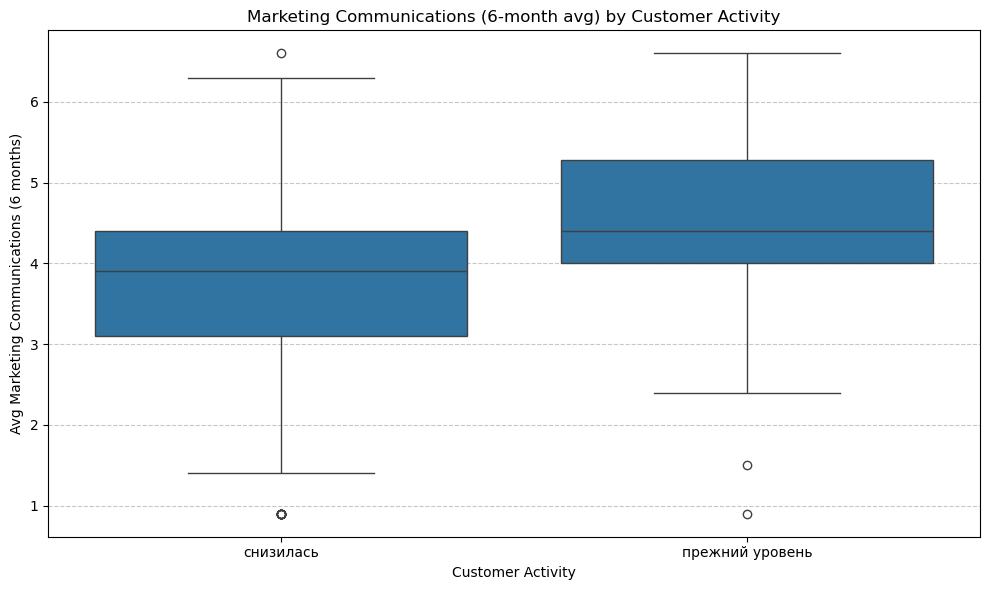

In [29]:
# Marketing communications distribution by activity
plt.figure(figsize=(10, 6))
sns.boxplot(x='buying_activity', y='marketing_6_mon_avg', data=market_file_df)
plt.title('Marketing Communications (6-month avg) by Customer Activity')
plt.xlabel('Customer Activity')
plt.ylabel('Avg Marketing Communications (6 months)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('reports/images/marketing_by_activity.png', dpi=150, bbox_inches='tight')
plt.show()

**Marketing Communications (6-month average):**
- Customers with **stable activity** receive noticeably more marketing communications on average
- Both groups have outliers near zero, indicating some customers receive minimal communication
- Median for **stable** group is 4.5, higher than **declined** group (3.9), confirming the difference in engagement intensity

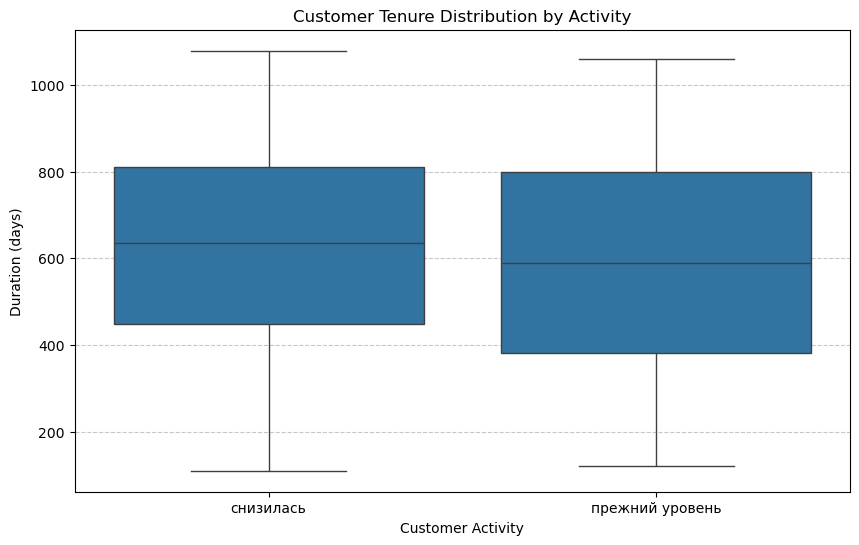

In [30]:
# Duration distribution by activity
plt.figure(figsize=(10, 6))
sns.boxplot(x='buying_activity', y='duration', data=market_file_df)
plt.title('Customer Tenure Distribution by Activity')
plt.xlabel('Customer Activity')
plt.ylabel('Duration (days)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

**Customer Duration:**
- Duration ranges are similar for both groups, with nearly identical min/max values
- Medians are around 600 days for both groups, showing no significant difference
- The **declined** group has a slightly higher Q1 value
- Preliminary conclusion: customer tenure likely doesn't significantly impact activity decline

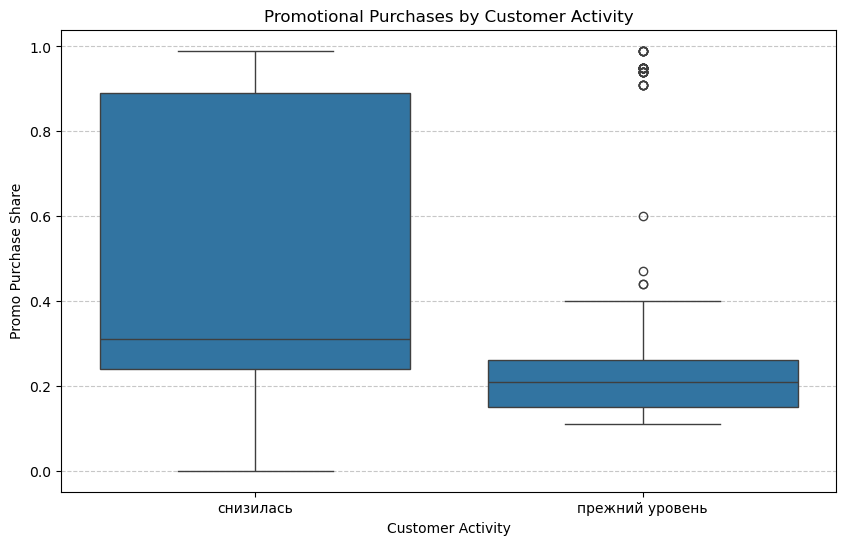

In [31]:
# Promotional purchases by activity
plt.figure(figsize=(10, 6))
sns.boxplot(x='buying_activity', y='promo_purchases', data=market_file_df)
plt.title('Promotional Purchases by Customer Activity')
plt.xlabel('Customer Activity')
plt.ylabel('Promo Purchase Share')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

**Promotional Purchases:**
- Customers with **declined activity** purchase promotional items significantly more often
- The **stable** group has outliers, indicating some users actively use promotions despite the general trend
- Median for declined group is **0.3**, higher than stable group (**0.2**)
- This difference suggests promotional shoppers may have lower long-term loyalty

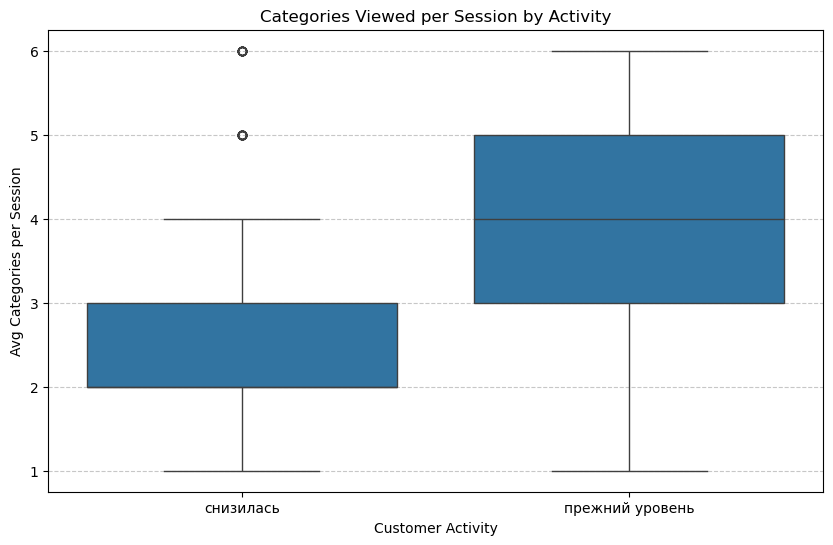

In [32]:
# Categories viewed per session by activity
plt.figure(figsize=(10, 6))
sns.boxplot(x='buying_activity', y='session_cat_avg', data=market_file_df)
plt.title('Categories Viewed per Session by Activity')
plt.xlabel('Customer Activity')
plt.ylabel('Avg Categories per Session')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

**Categories Viewed per Session:**
- Average categories viewed differs significantly between groups
- **Declined** group views fewer categories: Q1-Q3 range is only 2-2, showing very low variability
- **Stable** group shows much wider range: median ~4 categories, Q3 ~5, indicating higher engagement

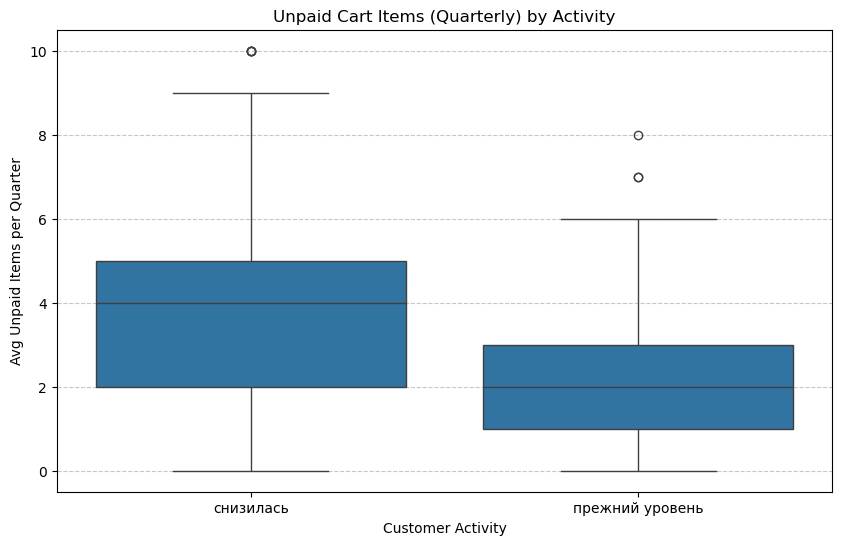

In [33]:
# Unpaid cart items by activity
plt.figure(figsize=(10, 6))
sns.boxplot(x='buying_activity', y='card_items_quorter_avg', data=market_file_df)
plt.title('Unpaid Cart Items (Quarterly) by Activity')
plt.xlabel('Customer Activity')
plt.ylabel('Avg Unpaid Items per Quarter')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

**Unpaid Cart Items:**
- Customers with **stable activity** have about half the unpaid cart items compared to **declined** group
- Median for declined group is **4**, versus **2** for stable group
- Stable group has outliers, indicating some users still leave items unpaid
- Higher cart abandonment may indicate purchase intent without completion — a warning sign

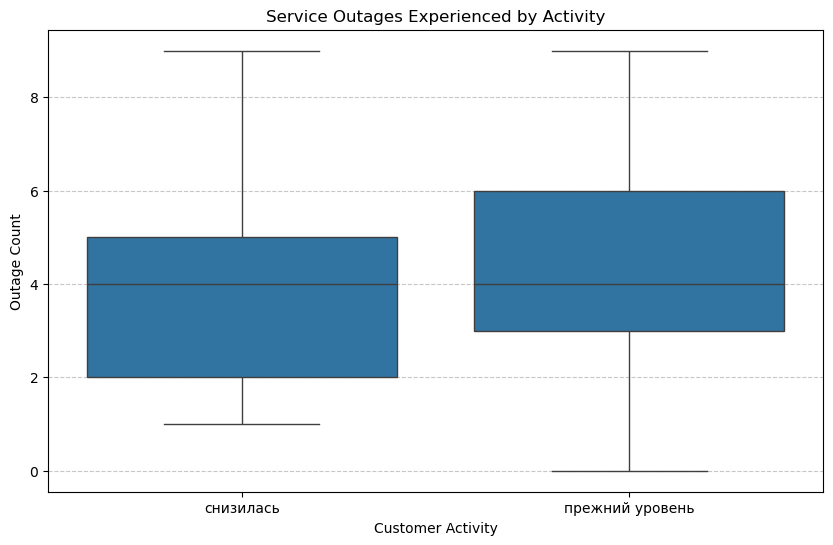

In [34]:
# Service outages by activity
plt.figure(figsize=(10, 6))
sns.boxplot(x='buying_activity', y='downtime_count', data=market_file_df)
plt.title('Service Outages Experienced by Activity')
plt.xlabel('Customer Activity')
plt.ylabel('Outage Count')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

**Service Outages:**
- Median outage count equals **4** for both groups, indicating similar system availability
- **Stable** group has wider value range, possibly due to more frequent service usage
- Based on this chart, customer activity likely **doesn't depend** on service outages

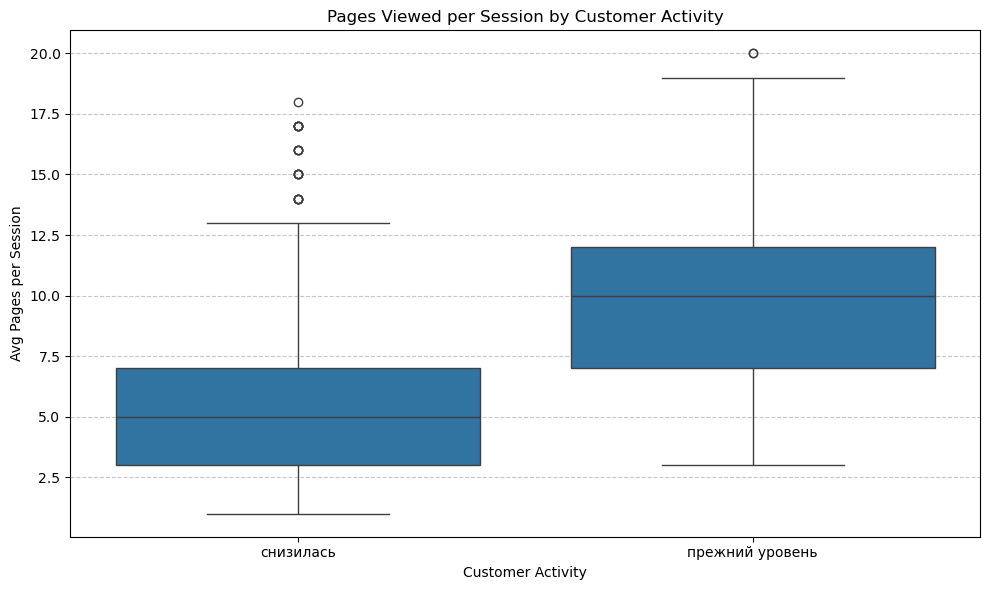

In [35]:
# Pages viewed per session by activity (key predictor)
plt.figure(figsize=(10, 6))
sns.boxplot(x='buying_activity', y='session_pages_avg', data=market_file_df)
plt.title('Pages Viewed per Session by Customer Activity')
plt.xlabel('Customer Activity')
plt.ylabel('Avg Pages per Session')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('reports/images/pages_by_activity.png', dpi=150, bbox_inches='tight')
plt.show()

**Pages Viewed per Session:**
- Users with **declined activity** viewed significantly fewer pages in the last quarter (logical given their reduced activity)
- **Median** for stable users is **10 pages**, versus **5 pages** for declined users
- Stable group shows wider range with outliers, indicating high variability in engagement

#### Distribution Analysis: `market_money_df`

In [36]:
# Get revenue statistics
market_money_df['revenue'].describe()

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: revenue, dtype: float64

- Minimum value is 0
- 25th percentile is 4,590 rubles, significantly above minimum
- Maximum is 20x higher than the 75th percentile

Let's build a box plot to identify outliers.

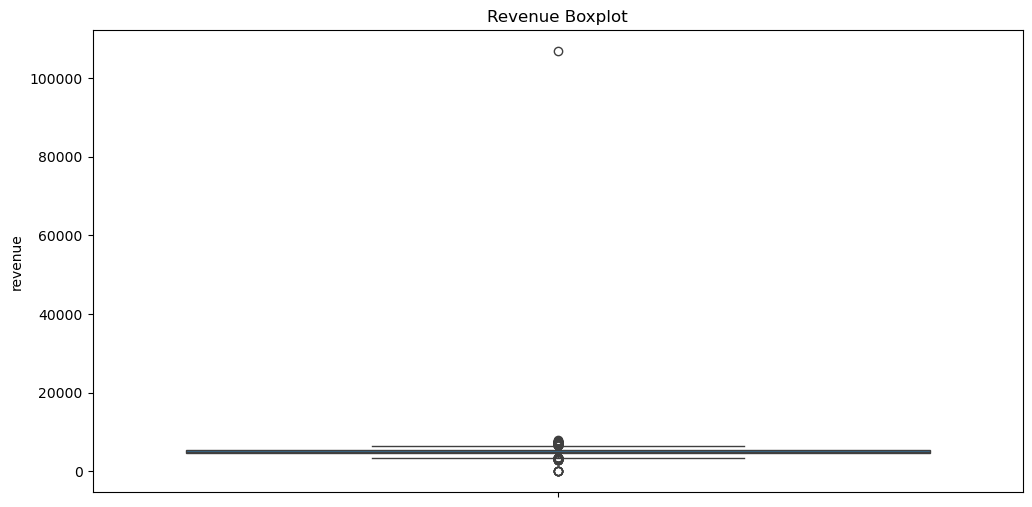

In [37]:
# Revenue boxplot to identify outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=market_money_df['revenue'])
plt.title("Revenue Boxplot")
plt.show()

The box plot shows a clear outlier at `100,000` and some values concentrated near 0. Since most values fall within `10,000`, such extreme outliers could negatively impact modeling. We'll remove outliers by limiting values to `10,000` rubles. Values near 0 indicate customers who made no purchases during the period — we'll keep these.

In [38]:
# Limit revenue to 10000 to remove extreme outliers
market_money_df = market_money_df[market_money_df['revenue'] < 10000]

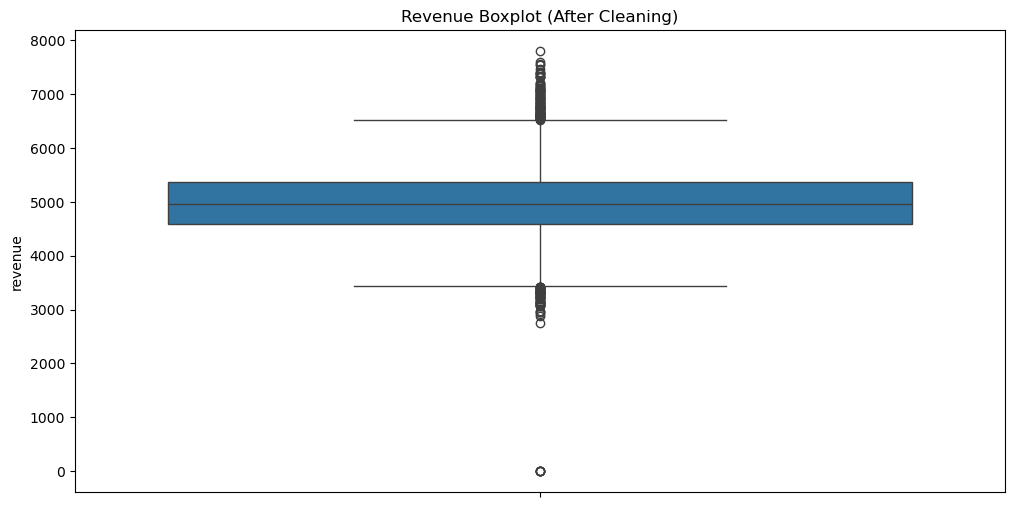

In [39]:
# Verify outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=market_money_df['revenue'])
plt.title("Revenue Boxplot (After Cleaning)")
plt.show()

After removing critical outliers, we see a more compact distribution. Despite many points beyond the whiskers, we'll keep this data as it's most representative for further analysis.

In [40]:
# Get time on site statistics
market_time_df['mins'].describe()

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: mins, dtype: float64

Data appears normally distributed with no outliers.

In [41]:
# Get income statistics
money_df['income'].describe()

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: income, dtype: float64

Data also appears normally distributed with no outliers. Let's summarize our findings and move to categorical analysis.

#### Key Findings: Numerical Features

- **Marketing Communications:** Higher average and median for stable group, suggesting positive impact on retention
- **Categories & Pages Viewed:** Stable customers view more, indicating higher engagement
- **Promotional Purchases:** Declined customers participate more in promotions — possibly price-sensitive, lower loyalty
- **Cart Abandonment:** Higher in declined group — potential indicator of purchase hesitation

### Categorical Features Analysis

For categorical analysis, we'll visualize category distributions by target variable to understand which categories are more common among active vs. inactive users.

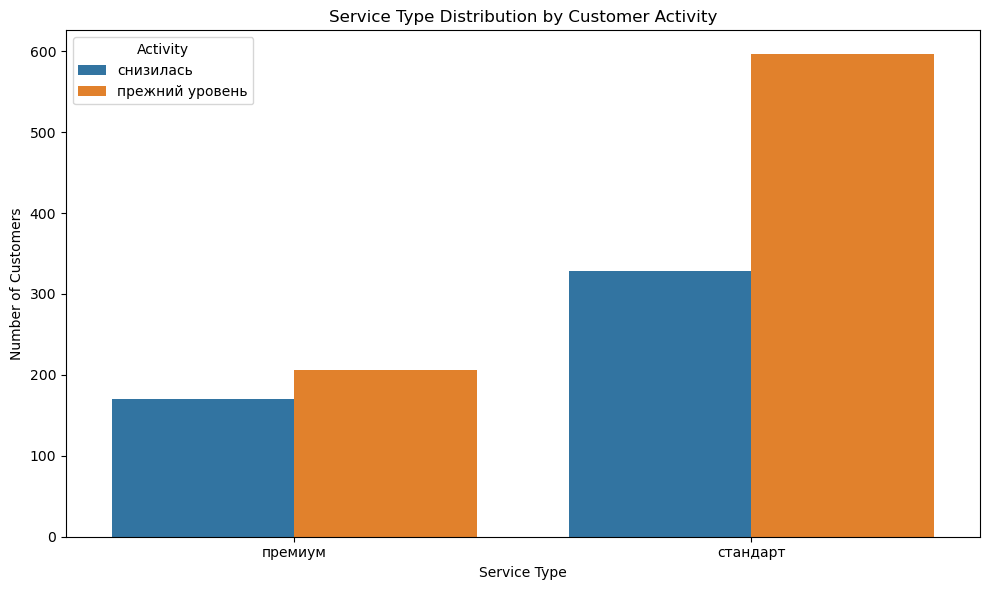

In [42]:
# Service type distribution by activity
plt.figure(figsize=(10, 6))
sns.countplot(x='service_type', hue='buying_activity', data=market_file_df)
plt.title('Service Type Distribution by Customer Activity')
plt.xlabel('Service Type')
plt.ylabel('Number of Customers')
plt.legend(title='Activity')
plt.tight_layout()
plt.savefig('reports/images/service_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Service Type:**
- **Premium subscribers:** ~50% show activity decline — minimal difference between activity levels, suggesting risk of losing premium users
- **Standard subscribers:** Activity decline is half as common — most maintain stable activity, indicating more stable engagement

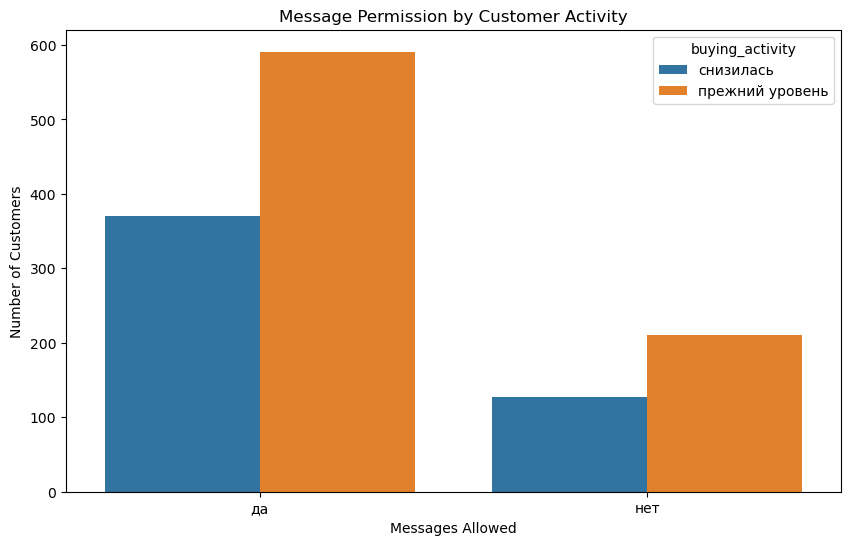

In [43]:
# Message permission distribution by activity
plt.figure(figsize=(10, 6))
sns.countplot(x='messages_allowed', hue='buying_activity', data=market_file_df)
plt.title("Message Permission by Customer Activity")
plt.xlabel('Messages Allowed')
plt.ylabel('Number of Customers')
plt.show()

**Message Permission:**
- **Messages allowed:** ~60% declined activity relative to stable users
- **Messages blocked:** Similar pattern — ~60% declined relative to stable users
- Message permission doesn't appear to significantly differentiate activity levels

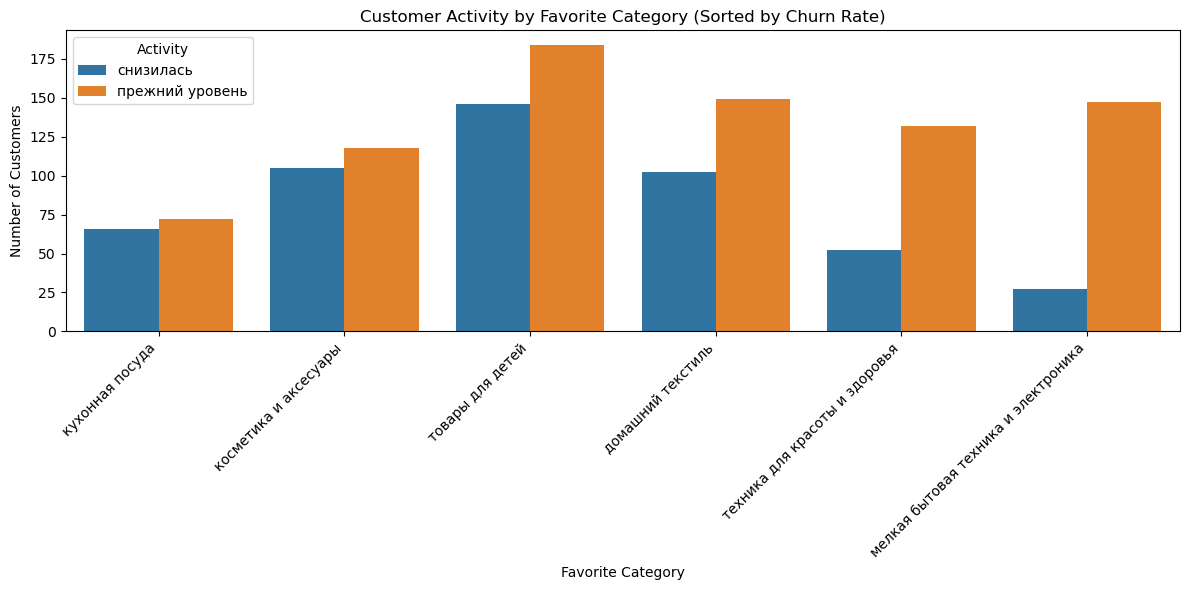

In [44]:
# Calculate churn rate by favorite category
category_ratios = (
    market_file_df
    .pivot_table(index='favourite_cat', columns='buying_activity', aggfunc='size', fill_value=0)
    .assign(ratio=lambda x: x['снизилась'] / (x['прежний уровень'] + x['снизилась']))
    .sort_values(by='ratio', ascending=False)
)

sorted_categories = category_ratios.index

# Plot categories with activity
plt.figure(figsize=(12, 6))
sns.countplot(x='favourite_cat', hue='buying_activity', data=market_file_df, order=sorted_categories)
plt.title('Customer Activity by Favorite Category (Sorted by Churn Rate)')
plt.xlabel('Favorite Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Activity')
plt.tight_layout()
plt.savefig('reports/images/category_churn.png', dpi=150, bbox_inches='tight')
plt.show()

**Favorite Categories:**
- **Highest decline rates** in "kitchenware", "cosmetics & accessories", and "children's products"
- **"Children's products"** has the most users overall, including those who declined
- This category is a key segment requiring retention focus due to high user concentration with churn risk

**Categorical Features Summary**

- **Service Type:** Premium users show higher churn risk (~50%) vs. standard users
- **Message Permission:** ~60% decline rate regardless of message settings — not a differentiating factor
- **Popular Categories:** "Children's products" is critical — highest user count including those churning. High priority for retention efforts.

### Merging Tables

For deeper analysis, we'll merge data from `market_file`, `market_money`, and `market_time` tables.

In [45]:
# Merge market_file_df with market_money_df
merged_full_df = market_file_df.merge(market_money_df, on="id", how="left")

# Add market_time_df
merged_full_df = merged_full_df.merge(market_time_df, on=["id", "period"], how="left")

# Pivot to create columns for each period
final_pivoted_df = merged_full_df.pivot_table(
    index=["id", "buying_activity", "service_type"],
    columns="period",
    values=["revenue", "mins"],
    aggfunc="first"
)

# Flatten column names
final_pivoted_df.columns = ["_".join(col).strip() for col in final_pivoted_df.columns.values]
final_pivoted_df = final_pivoted_df.reset_index()

# Merge with original market_file
final_merged_df = market_file_df.merge(final_pivoted_df, on=["id", "buying_activity", "service_type"], how="left")

# Add income data
final_merged_df = final_merged_df.merge(money_df, on="id", how="left")

In [46]:
# Preview merged dataframe
final_merged_df.head()

,id,buying_activity,service_type,messages_allowed,marketing_6_mon_avg,marketing_curr_mon,duration,promo_purchases,favourite_cat,session_cat_avg,card_items_quorter_avg,downtime_count,session_pages_avg,mins_предыдущий_месяц,mins_текущий_месяц,revenue_предыдущий_месяц,revenue_препредыдущий_месяц,revenue_текущий_месяц,income
0,215348,снизилась,премиум,да,3.4,5,121,0.00,товары для детей,6,2,1,5,13.0,14.0,0.0,0.0,3293.1,0.98
1,215349,снизилась,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5,12.0,10.0,5216.0,4472.0,4971.6,4.16
2,215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний текстиль,5,2,1,5,8.0,13.0,5457.5,4826.0,5058.4,3.13
3,215351,снизилась,стандарт,да,3.2,5,896,0.99,товары для детей,5,0,6,4,11.0,13.0,6158.0,4793.0,6610.4,4.87
4,215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары для детей,3,2,3,2,8.0,11.0,5807.5,4594.0,5872.5,4.21


In [47]:
final_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           1300 non-null   int64  
 1   buying_activity              1300 non-null   object 
 2   service_type                 1300 non-null   object 
 3   messages_allowed             1300 non-null   object 
 4   marketing_6_mon_avg          1300 non-null   float64
 5   marketing_curr_mon           1300 non-null   int64  
 6   duration                     1300 non-null   int64  
 7   promo_purchases              1300 non-null   float64
 8   favourite_cat                1300 non-null   object 
 9   session_cat_avg              1300 non-null   int64  
 10  card_items_quorter_avg       1300 non-null   int64  
 11  downtime_count               1300 non-null   int64  
 12  session_pages_avg            1300 non-null   int64  
 13  mins_предыдущий_ме

Let's remove inactive users — those with zero revenue in any period. We'll keep only users with non-zero, non-null values across all three periods.

In [48]:
final_merged_df = final_merged_df[
    ((final_merged_df['revenue_препредыдущий_месяц'] != 0) & (~final_merged_df['revenue_препредыдущий_месяц'].isna())) &
    ((final_merged_df['revenue_предыдущий_месяц'] != 0) & (~final_merged_df['revenue_предыдущий_месяц'].isna())) &
    ((final_merged_df['revenue_текущий_месяц'] != 0) & (~final_merged_df['revenue_текущий_месяц'].isna()))
]

In [49]:
# Verify the cleaned dataframe
final_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296 entries, 1 to 1299
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           1296 non-null   int64  
 1   buying_activity              1296 non-null   object 
 2   service_type                 1296 non-null   object 
 3   messages_allowed             1296 non-null   object 
 4   marketing_6_mon_avg          1296 non-null   float64
 5   marketing_curr_mon           1296 non-null   int64  
 6   duration                     1296 non-null   int64  
 7   promo_purchases              1296 non-null   float64
 8   favourite_cat                1296 non-null   object 
 9   session_cat_avg              1296 non-null   int64  
 10  card_items_quorter_avg       1296 non-null   int64  
 11  downtime_count               1296 non-null   int64  
 12  session_pages_avg            1296 non-null   int64  
 13  mins_предыдущий_месяц  

Records for four inactive users have been removed.

#### Revenue Analysis by Period
- Let's plot total revenue for each of the three periods to see the overall trend
- Then visualize revenue distribution by activity groups (`buying_activity`)

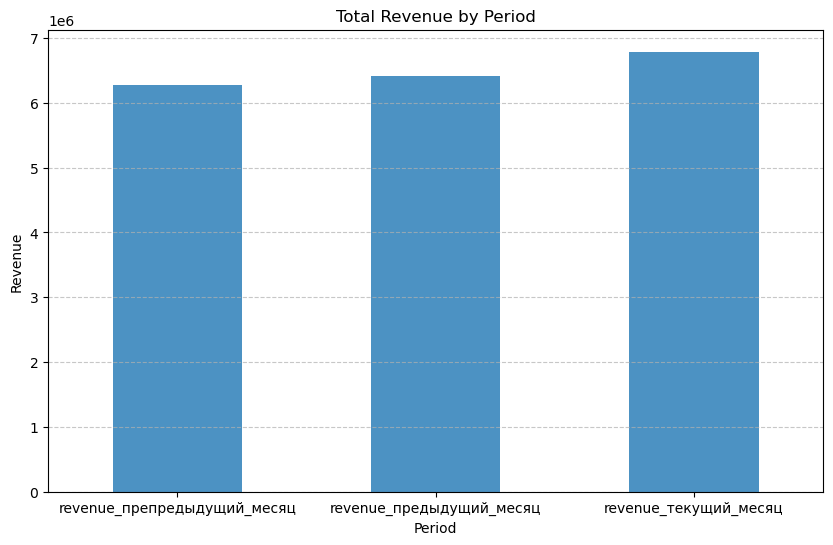

In [50]:
# Total revenue by period
total_revenue_by_period = final_merged_df[
    ['revenue_препредыдущий_месяц', 'revenue_предыдущий_месяц', 'revenue_текущий_месяц']
].sum()

# Plot total revenue
plt.figure(figsize=(10, 6))
total_revenue_by_period.plot(kind='bar', alpha=0.8)
plt.title('Total Revenue by Period')
plt.xlabel('Period')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Revenue has grown over the last three months, reaching its maximum in the current month.

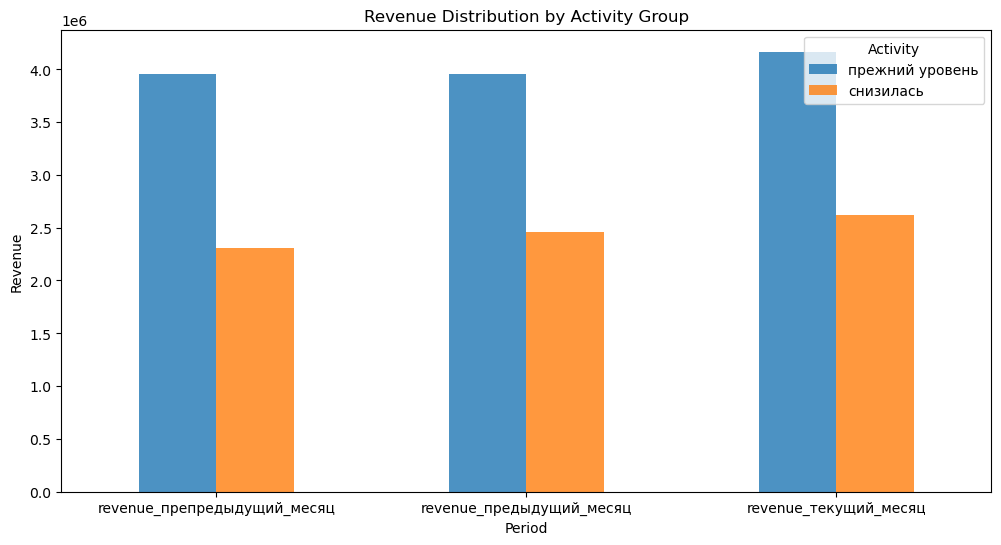

In [51]:
# Revenue by activity group
revenue_by_activity = final_merged_df.groupby('buying_activity')[
    ['revenue_препредыдущий_месяц', 'revenue_предыдущий_месяц', 'revenue_текущий_месяц']
].sum()

# Plot revenue distribution by activity
revenue_by_activity.T.plot(kind='bar', figsize=(12, 6), alpha=0.8)
plt.title('Revenue Distribution by Activity Group')
plt.xlabel('Period')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.legend(title='Activity')
plt.show()

Despite overall revenue growth in the last three months, the share of users with declined activity has also increased.

#### Dynamics Analysis

- **Revenue Dynamics:**
    - Calculate revenue difference between periods for each user with declined activity
    - Identify users with the largest negative dynamics and analyze their behavior
- **Time on Site Dynamics:**
    - Similar calculation for time spent on site to identify users spending less time

In [52]:
# Calculate revenue dynamics
activity_groups_df = final_merged_df.copy()
activity_groups_df["revenue_change_current_previous"] = (
    activity_groups_df["revenue_текущий_месяц"] - activity_groups_df["revenue_предыдущий_месяц"]
)
activity_groups_df["revenue_change_previous_preprevious"] = (
    activity_groups_df["revenue_предыдущий_месяц"] - activity_groups_df["revenue_препредыдущий_месяц"]
)

# Calculate time dynamics
activity_groups_df["time_change_current_previous"] = (
    activity_groups_df["mins_текущий_месяц"] - activity_groups_df["mins_предыдущий_месяц"]
)

In [53]:
# Find users with largest revenue decline
negative_revenue_change = activity_groups_df[
    (activity_groups_df["revenue_change_current_previous"] < 0) |
    (activity_groups_df["revenue_change_previous_preprevious"] < 0)
]
negative_revenue_change.sort_values(by=["revenue_change_current_previous", "revenue_change_previous_preprevious"]).head()

,id,buying_activity,service_type,messages_allowed,marketing_6_mon_avg,marketing_curr_mon,duration,promo_purchases,favourite_cat,session_cat_avg,...,session_pages_avg,mins_предыдущий_месяц,mins_текущий_месяц,revenue_предыдущий_месяц,revenue_препредыдущий_месяц,revenue_текущий_месяц,income,revenue_change_current_previous,revenue_change_previous_preprevious,time_change_current_previous
13,215361,снизилась,стандарт,да,5.1,4,199,0.23,техника для красоты и здоровья,4,...,3,11.0,13.0,6400.0,4597.0,3789.7,4.03,-2610.3,1803.0,2.0
895,216243,прежний уровень,стандарт,да,3.3,5,812,0.11,косметика и аксесуары,4,...,5,12.0,19.0,4438.0,5485.0,3660.6,2.79,-777.4,-1047.0,7.0
667,216015,прежний уровень,стандарт,да,5.4,3,629,0.21,домашний текстиль,6,...,6,15.0,19.0,4466.0,5492.0,3706.8,3.60,-759.2,-1026.0,4.0
1057,216405,прежний уровень,стандарт,да,4.0,4,436,0.21,мелкая бытовая техника и электроника,4,...,9,17.0,21.0,4637.0,5663.0,3877.8,3.30,-759.2,-1026.0,4.0
970,216318,прежний уровень,премиум,да,3.9,5,1040,0.30,косметика и аксесуары,2,...,14,21.0,16.0,4108.5,5118.0,3363.6,4.83,-744.9,-1009.5,-5.0


In [54]:
# Find users with largest time decline
negative_time_change = activity_groups_df[activity_groups_df["time_change_current_previous"] < 0]
negative_time_change.sort_values(by="time_change_current_previous").head()

,id,buying_activity,service_type,messages_allowed,marketing_6_mon_avg,marketing_curr_mon,duration,promo_purchases,favourite_cat,session_cat_avg,...,session_pages_avg,mins_предыдущий_месяц,mins_текущий_месяц,revenue_предыдущий_месяц,revenue_препредыдущий_месяц,revenue_текущий_месяц,income,revenue_change_current_previous,revenue_change_previous_preprevious,time_change_current_previous
1007,216355,прежний уровень,стандарт,да,5.1,4,433,0.14,товары для детей,4,...,9,20.0,5.0,4005.0,4768.0,4796.7,3.19,791.7,-763.0,-15.0
1095,216443,прежний уровень,стандарт,нет,4.8,4,322,0.17,домашний текстиль,2,...,6,21.0,6.0,5140.0,5029.0,5366.2,2.92,226.2,111.0,-15.0
1285,216633,прежний уровень,стандарт,нет,2.4,4,192,0.35,техника для красоты и здоровья,3,...,10,20.0,6.0,5311.0,4651.0,6013.0,3.39,702.0,660.0,-14.0
510,215858,прежний уровень,стандарт,да,5.5,4,510,0.15,мелкая бытовая техника и электроника,2,...,16,20.0,6.0,5170.5,4347.0,6014.2,4.37,843.7,823.5,-14.0
507,215855,прежний уровень,стандарт,да,5.5,5,149,0.20,кухонная посуда,3,...,6,21.0,8.0,5634.5,4682.0,6590.0,5.55,955.5,952.5,-13.0


<Figure size 1000x600 with 0 Axes>

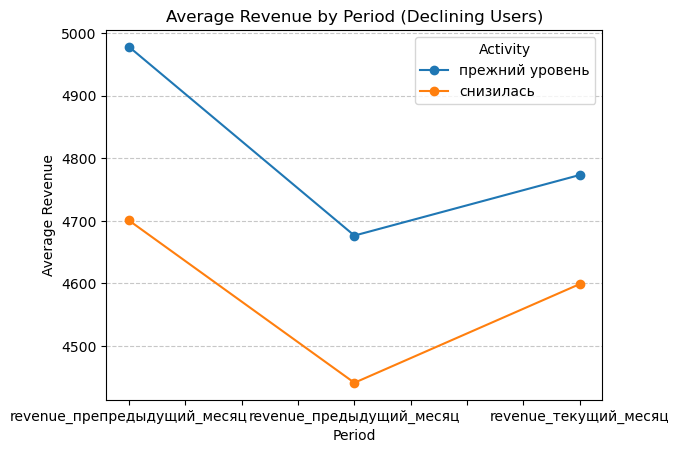

In [55]:
# Average revenue by period for declining users
average_revenue_negative = negative_revenue_change.groupby("buying_activity")[
    ["revenue_препредыдущий_месяц", "revenue_предыдущий_месяц", "revenue_текущий_месяц"]
].mean()

# Plot
plt.figure(figsize=(10, 6))
average_revenue_negative.T.plot(marker="o")
plt.title("Average Revenue by Period (Declining Users)")
plt.xlabel("Period")
plt.ylabel("Average Revenue")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Activity")
plt.show()

**Revenue Dynamics:**
- Both groups show similar "U-shaped" dynamics: revenue drops mid-period, then partially recovers
- This may reflect seasonal or marketing effects affecting all users equally
- However, the **declined group** has a significantly lower baseline revenue, confirming their reduced purchasing power

<Figure size 1000x600 with 0 Axes>

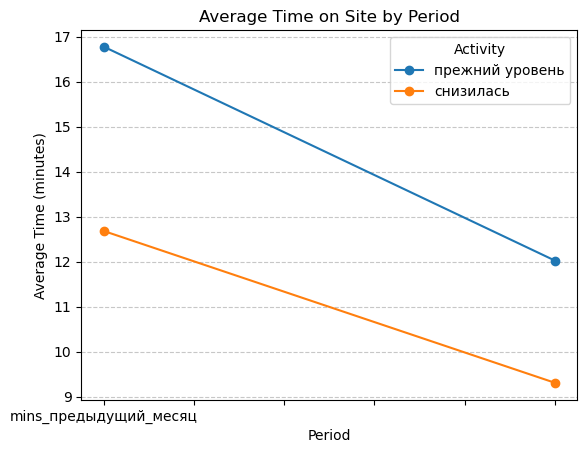

In [56]:
# Average time on site for declining users
average_time_negative = negative_time_change.groupby("buying_activity")[
    ["mins_предыдущий_месяц", "mins_текущий_месяц"]
].mean()

# Plot
plt.figure(figsize=(10, 6))
average_time_negative.T.plot(marker="o")
plt.title("Average Time on Site by Period")
plt.xlabel("Period")
plt.ylabel("Average Time (minutes)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Activity")
plt.show()

**Time on Site Dynamics:**
1. **Both groups show declining time:**
    - Time spent on site decreases from previous to current month for both groups
    - This may indicate declining platform interest or lack of engagement incentives
2. **Declined group starts lower:**
    - This group's time on site is initially lower, confirming less engaged behavior
3. **Parallel trends:**
    - Both groups follow nearly parallel trajectories, suggesting the decline isn't group-specific

### EDA Summary

- **Numerical Features:**
    - Marketing communications positively correlate with activity: stable group shows higher averages and medians
    - Categories and pages viewed are higher for active users, indicating greater engagement
    - Declined users make more promotional purchases, suggesting price-driven, situational buying
    - Cart abandonment is higher in the declined group
    
- **Categorical Features:**
    - Premium users show higher churn risk (~50%)
    - Message permission doesn't significantly differentiate activity levels
    - "Children's products" category is critical for retention

## Correlation Analysis

### Multicollinearity Check

For detailed multicollinearity analysis, we'll use the `phik` library.

In [57]:
# Drop id column (not useful for analysis)
final_merged_df = final_merged_df.drop(columns=['id'], axis=1)

# List all columns
final_merged_df.columns

Index(['buying_activity', 'service_type', 'messages_allowed',
       'marketing_6_mon_avg', 'marketing_curr_mon', 'duration',
       'promo_purchases', 'favourite_cat', 'session_cat_avg',
       'card_items_quorter_avg', 'downtime_count', 'session_pages_avg',
       'mins_предыдущий_месяц', 'mins_текущий_месяц',
       'revenue_предыдущий_месяц', 'revenue_препредыдущий_месяц',
       'revenue_текущий_месяц', 'income'],
      dtype='object')

In [58]:
# Numeric features for correlation analysis
numeric_features = ["marketing_6_mon_avg", "duration", "promo_purchases",
                    "revenue_предыдущий_месяц", "revenue_препредыдущий_месяц",
                    "revenue_текущий_месяц"]

# Calculate correlation matrix with phik
correlation_matrix = final_merged_df.phik_matrix(interval_cols=numeric_features)

# Display
correlation_matrix

,buying_activity,service_type,messages_allowed,marketing_6_mon_avg,marketing_curr_mon,duration,promo_purchases,favourite_cat,session_cat_avg,card_items_quorter_avg,downtime_count,session_pages_avg,mins_предыдущий_месяц,mins_текущий_месяц,revenue_предыдущий_месяц,revenue_препредыдущий_месяц,revenue_текущий_месяц,income
buying_activity,1.000000,0.129940,0.000000,0.544831,0.000000,0.099901,0.506276,0.299717,0.539607,0.405041,0.224154,0.747331,0.604355,0.569983,0.224638,0.497393,0.197213,0.095136
service_type,0.129940,1.000000,0.289965,0.089911,0.045258,0.401411,0.030010,0.070809,0.185391,0.113015,0.079515,0.087776,0.121210,0.061764,0.000000,0.069704,0.124216,0.061584
messages_allowed,0.000000,0.289965,1.000000,0.000000,0.052618,0.253831,0.012198,0.073684,0.070359,0.162524,0.021839,0.097094,0.063528,0.000000,0.080842,0.000000,0.060907,0.049746
marketing_6_mon_avg,0.544831,0.089911,0.000000,1.000000,0.079854,0.000000,0.279553,0.150386,0.206788,0.217731,0.142401,0.376035,0.322830,0.331480,0.155476,0.315331,0.039795,0.155078
marketing_curr_mon,0.000000,0.045258,0.052618,0.079854,1.000000,0.174233,0.000000,0.136243,0.246633,0.142887,0.116946,0.000000,0.166871,0.079883,0.051824,0.000000,0.000000,0.095890
duration,0.099901,0.401411,0.253831,0.000000,0.174233,1.000000,0.000000,0.000000,0.186795,0.128222,0.175608,0.128089,0.046299,0.021117,0.125572,0.113200,0.147048,0.266791
promo_purchases,0.506276,0.030010,0.012198,0.279553,0.000000,0.000000,1.000000,0.122385,0.199180,0.246665,0.000000,0.350714,0.314140,0.287292,0.060733,0.226381,0.071094,0.394778
favourite_cat,0.299717,0.070809,0.073684,0.150386,0.136243,0.000000,0.122385,1.000000,0.226116,0.254746,0.000000,0.177637,0.218727,0.113774,0.252097,0.043528,0.237240,0.036567
session_cat_avg,0.539607,0.185391,0.070359,0.206788,0.246633,0.186795,0.199180,0.226116,1.000000,0.334927,0.070315,0.293781,0.219174,0.236298,0.098440,0.176828,0.092597,0.294047
card_items_quorter_avg,0.405041,0.113015,0.162524,0.217731,0.142887,0.128222,0.246665,0.254746,0.334927,1.000000,0.000000,0.310843,0.194298,0.158243,0.193536,0.189320,0.166017,0.503989


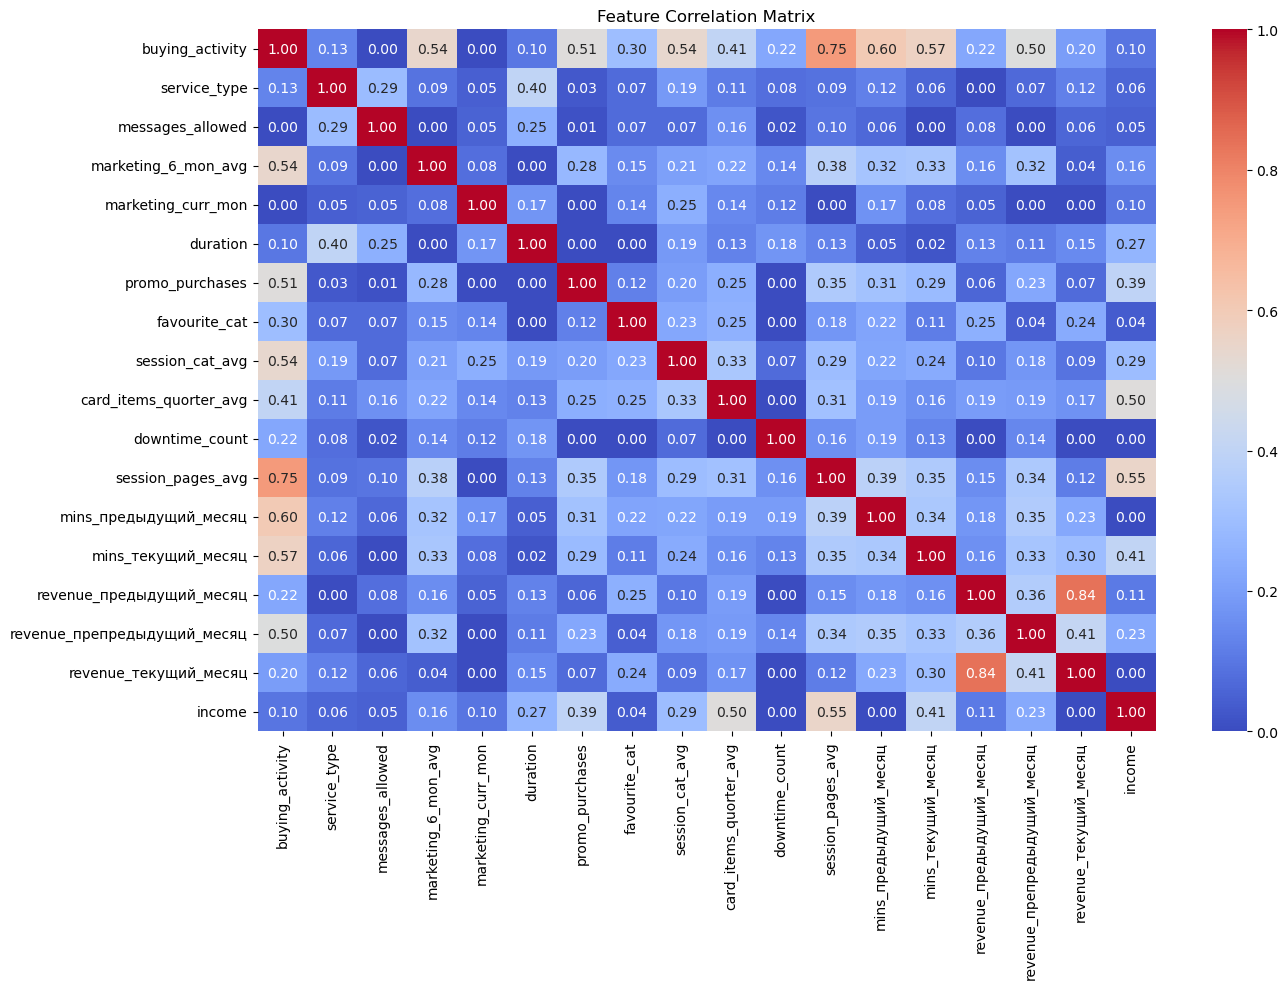

In [59]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('reports/images/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Correlation Analysis Results:**

1. **Strong Correlations (>0.8):**
    - `revenue_previous_month` and `revenue_current_month` (0.84)

2. **Medium Correlations (0.4–0.8):**
    - `buying_activity` and `session_pages_avg` (0.75)
    - `buying_activity` and `mins_previous_month` (0.60)
    - `buying_activity` and `mins_current_month` (0.57)
    - `buying_activity` and `marketing_6_mon_avg` (0.54)
    - `buying_activity` and `session_cat_avg` (0.54)
    - `buying_activity` and `promo_purchases` (0.51)

There's moderate correlation (0.84) between `revenue_previous_month` and `revenue_current_month`. This isn't critical enough to remove features, but we'll address it through regularization during modeling.

## Model Pipeline

### Data Preparation

Let's split the data into training and test sets using stratification to preserve class balance.

In [60]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

# Split features and target
X = final_merged_df.drop(['buying_activity'], axis=1)
y = final_merged_df['buying_activity']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = y
)

Creating feature lists grouped by encoder/scaler type:
- **OneHotEncoder** for categorical variables (no inherent order)
- **StandardScaler** for numerical variables with near-normal distribution
- **MinMaxScaler** for remaining numerical variables

In [61]:
# Create feature lists by encoding type
ohe_columns = ['favourite_cat']

ord_columns = ['service_type', 'messages_allowed']

num_columns = ['marketing_6_mon_avg', 'marketing_curr_mon', 'duration',
               'promo_purchases', 'session_cat_avg',
               'card_items_quorter_avg', 'downtime_count', 'session_pages_avg',
               'mins_предыдущий_месяц', 'mins_текущий_месяц',
               'revenue_препредыдущий_месяц', 'revenue_предыдущий_месяц', 'revenue_текущий_месяц']

### Pipeline Creation with `ColumnTransformer`

Creating the preprocessing pipeline using `ColumnTransformer`.

In [62]:
# Pipeline for OneHotEncoder
ohe_pipe = Pipeline(
    [
        (
            "simpleImputer_ohe", 
            SimpleImputer(missing_values=np.nan, strategy="most_frequent")
        ),
        (
            "ohe", 
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
        )
    ]
)

In [63]:
# Pipeline for OrdinalEncoder
ord_pipe = Pipeline(
    [
        (
            "simpleImputer_before_ord", 
            SimpleImputer(missing_values=np.nan, strategy="most_frequent")
        ),
        (
            "ord",
            OrdinalEncoder(
                categories=[
                    ["стандарт", "премиум"],
                    ["нет", "да"]
                ], 
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

In [64]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns),
    ], 
    remainder='passthrough'
)

### Model Selection Pipeline

In [65]:
# Final pipeline with model selection
pipe_final = Pipeline([
    ("preprocessor", data_preprocessor),
    ("models", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid = [
    # DecisionTreeClassifier
    {
        "models": [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        "models__max_depth": range(2, 5),
        "models__max_features": range(2, 5),
        "preprocessor__num": [StandardScaler(), MinMaxScaler(), "passthrough"]
    },
    # LogisticRegression
    {
        "models": [LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)],
        "models__C": [0.1, 1, 10],
        "preprocessor__num": [StandardScaler(), MinMaxScaler()]
    },
    # KNeighborsClassifier
    {
        "models": [KNeighborsClassifier()],
        "models__n_neighbors": range(3, 10),
        "preprocessor__num": [StandardScaler(), MinMaxScaler()]
    },
    # SVC
    {
        "models": [SVC(probability=True, random_state=RANDOM_STATE)],
        "models__C": [0.1, 1, 10],
        "preprocessor__num": [StandardScaler(), MinMaxScaler()]
    }
]

### Hyperparameter Tuning

Using `RandomizedSearchCV` for hyperparameter search. We'll use `f1_weighted` as the scoring metric given the class imbalance.

In [66]:
# Initialize RandomizedSearchCV
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_distributions=param_grid, 
    scoring='f1_weighted', 
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit and find best parameters
randomized_search.fit(X_train, y_train)

print("Best parameters:", randomized_search.best_params_)
print("Best F1 score (CV):", randomized_search.best_score_)

Best parameters: {'preprocessor__num': StandardScaler(), 'models__C': 0.1, 'models': SVC(probability=True, random_state=42)}
Best F1 score (CV): 0.8698485590707368


**Best Model Found:** `SVC` with `StandardScaler`

**Cross-validation F1 score:** 0.87

### Model Evaluation

Let's build a comparison table of parameters and metrics for the best models.

In [67]:
result = pd.DataFrame(randomized_search.cv_results_)
result[['rank_test_score', 'param_models', 'mean_test_score','params']].sort_values('rank_test_score')

,rank_test_score,param_models,mean_test_score,params
2,1,"SVC(probability=True, random_state=42)",0.869849,"{'preprocessor__num': StandardScaler(), 'model..."
4,2,KNeighborsClassifier(),0.867611,"{'preprocessor__num': StandardScaler(), 'model..."
7,3,"SVC(probability=True, random_state=42)",0.865018,"{'preprocessor__num': MinMaxScaler(), 'models_..."
1,4,KNeighborsClassifier(),0.860159,"{'preprocessor__num': StandardScaler(), 'model..."
9,5,"LogisticRegression(max_iter=1000, random_state...",0.854891,"{'preprocessor__num': MinMaxScaler(), 'models_..."
0,6,DecisionTreeClassifier(random_state=42),0.755086,"{'preprocessor__num': MinMaxScaler(), 'models_..."
6,7,DecisionTreeClassifier(random_state=42),0.740720,"{'preprocessor__num': 'passthrough', 'models__..."
5,8,DecisionTreeClassifier(random_state=42),0.732596,"{'preprocessor__num': 'passthrough', 'models__..."
8,8,DecisionTreeClassifier(random_state=42),0.732596,"{'preprocessor__num': StandardScaler(), 'model..."
3,10,DecisionTreeClassifier(random_state=42),0.663189,"{'preprocessor__num': StandardScaler(), 'model..."


In [68]:
# Evaluate on test set
y_test_pred = randomized_search.predict(X_test)
print(f"F1 Score on Test Set: {f1_score(y_test, y_test_pred, average='weighted')}")

F1 Score on Test Set: 0.9148463356973996


The model performed better on the test set than during cross-validation — a good sign!

To validate model quality, we'll compare against `DummyClassifier`. If our model doesn't outperform the dummy baseline, the search needs to restart.

In [69]:
# Train and evaluate DummyClassifier as baseline
dummy_model = DummyClassifier(random_state=RANDOM_STATE)
dummy_model.fit(X_train, y_train)

# Predictions
dummy_model_preds = dummy_model.predict(X_test)
dummy_model_probas = dummy_model.predict_proba(X_test)[:,1]

# Calculate F1 score
dummy_f1 = f1_score(y_test, dummy_model_preds, average='weighted')
print(f"Baseline F1 Score (DummyClassifier): {dummy_f1}")

Baseline F1 Score (DummyClassifier): 0.475026455026455


**Baseline Comparison:**

`DummyClassifier` F1 score is almost **half** that of our SVC model. This confirms our model is learning meaningful patterns and is ready for production use.

## Feature Importance Analysis

### SHAP Analysis for Best Model

In [70]:
# Extract best pipeline and model
best_pipeline = randomized_search.best_estimator_
best_model = best_pipeline.named_steps["models"]
preprocessor = best_pipeline.named_steps["preprocessor"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Save subset for SHAP analysis
X_shap_sample = X_test_transformed[:50]

# Sample background data for SHAP
X_background = shap.sample(X_test_transformed, 100)

# Create SHAP KernelExplainer
explainer = shap.KernelExplainer(best_model.predict_proba, X_background)

# Calculate SHAP values on the same subset
shap_values = explainer.shap_values(X_shap_sample)

print(f"X_shap_sample shape: {X_shap_sample.shape}")
print(f"shap_values[0] shape: {shap_values[0].shape}")
print(f"shap_values[1] shape: {shap_values[1].shape}")

  0%|          | 0/50 [00:00<?, ?it/s]

X_shap_sample shape: (50, 21)
shap_values[0] shape: (21, 2)
shap_values[1] shape: (21, 2)


Feature names: 21
shap_values shape: (50, 21, 2)


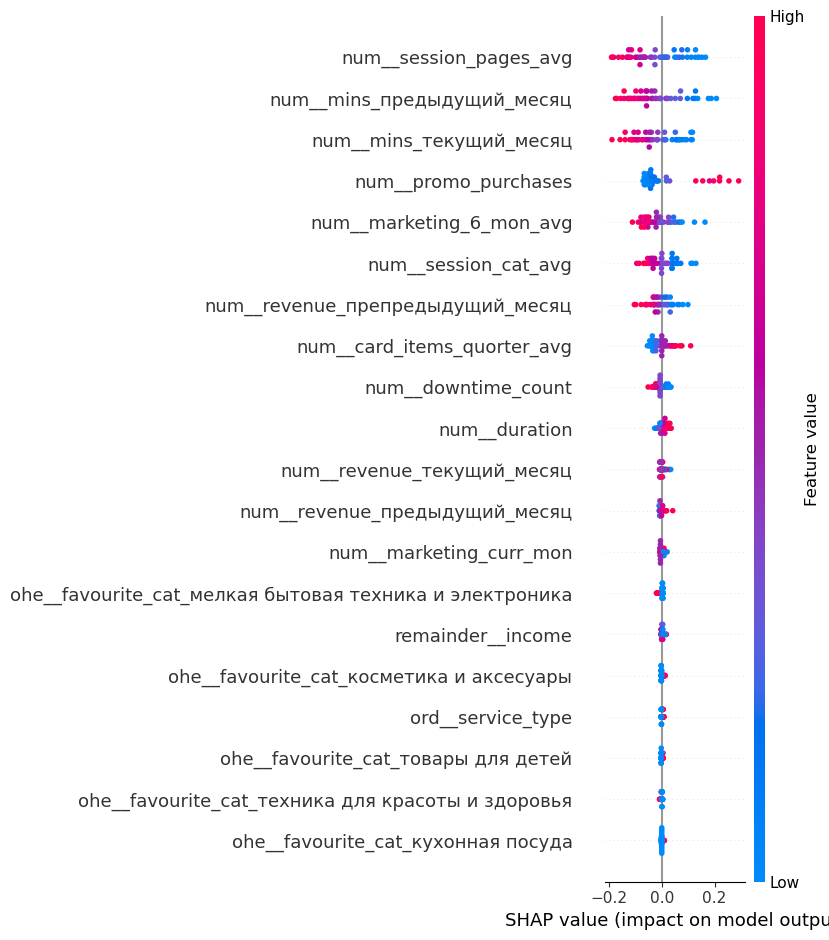

In [71]:
# Get feature names
all_feature_names = preprocessor.get_feature_names_out()
feature_names = list(all_feature_names)
print(f"Feature names: {len(feature_names)}")
print(f"shap_values shape: {shap_values.shape}")

# SHAP summary plot
# shap_values is (samples, features, classes) - use [:, :, 1] for class 1
if len(shap_values.shape) == 3:
    shap_class1 = shap_values[:, :, 1]
else:
    shap_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(shap_class1, X_shap_sample, feature_names=feature_names)

### Key Feature Insights

**Most Important Features:**
- `session_pages_avg`: Highest impact on predictions — average pages viewed per session strongly influences the target
- `mins_previous_month` and `mins_current_month`: Time spent on site plays a crucial role, indicating user engagement over time matters
- `marketing_6_mon_avg`: Marketing communication frequency contributes significantly
- `promo_purchases`: Promotional purchase behavior is also predictive

## Customer Segmentation

### Segmentation Approach

**Segmentation Goals:**
- Divide customers into groups based on key characteristics from each feature category
- Understand how different features affect activity and profitability

**Methodology:**
- Use K-Means clustering to segment customers
- Can use all features or summary statistics like:
    - Average communication frequency
    - Behavioral patterns
    - Revenue indicators

Organizing features into groups:
- Communication with customer
- Product behavior
- Site behavior
- Financial behavior

In [72]:
# Feature groups for segmentation
communication_features_cat = [
    'service_type', 'messages_allowed'
]
communication_features_num = [
    'marketing_6_mon_avg', 'marketing_curr_mon', 'duration'
]
communication_features = np.concatenate([communication_features_cat, communication_features_num])

product_features_cat = [
    'favourite_cat'
]
product_features_num = [
    'session_cat_avg', 'card_items_quorter_avg'
]
product_features = np.concatenate([product_features_cat, product_features_num])

site_behavior_features = [
    'downtime_count', 'session_pages_avg'
]

financial_features = [
    'revenue_препредыдущий_месяц', 'revenue_предыдущий_месяц', 'revenue_текущий_месяц',
    'mins_предыдущий_месяц', 'mins_текущий_месяц'
]

Scaling numerical data and encoding categorical features. Processing each group separately allows for specific transformations if needed later.

In [73]:
# Create preprocessors for each feature group
communication_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), communication_features_num),
        ('cat', ohe_pipe, communication_features_cat)
    ]
)
product_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), product_features_num),
        ('cat', ohe_pipe, product_features_cat)
    ]
)

In [74]:
scaler = StandardScaler()

# Select data for each segment
communication_data = final_merged_df[communication_features]
product_data = final_merged_df[product_features]
site_behavior_data = final_merged_df[site_behavior_features]
financial_data = final_merged_df[financial_features]

# Scale data
scaler = StandardScaler()
communication_data_scaled = communication_preprocessor.fit_transform(communication_data)
product_data_scaled = product_preprocessor.fit_transform(product_data)
site_behavior_data_scaled = scaler.fit_transform(site_behavior_data)
financial_data_scaled = scaler.fit_transform(financial_data)

Applying K-Means for segmentation:

In [75]:
# K-Means clustering for each feature group

# Communication segment
kmeans_communication = KMeans(n_clusters=3, random_state=42)
final_merged_df['Communication_Segment'] = kmeans_communication.fit_predict(communication_data_scaled)

# Product segment
kmeans_product = KMeans(n_clusters=3, random_state=42)
final_merged_df['Product_Segment'] = kmeans_product.fit_predict(product_data_scaled)

# Site behavior segment
kmeans_site = KMeans(n_clusters=3, random_state=42)
final_merged_df['Site_Segment'] = kmeans_site.fit_predict(site_behavior_data_scaled)

# Financial segment
kmeans_financial = KMeans(n_clusters=3, random_state=42)
final_merged_df['Financial_Segment'] = kmeans_financial.fit_predict(financial_data_scaled)

C:\Users\Арина\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Арина\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Арина\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Арина\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_

### Segment Selection

For detailed analysis, we'll focus on the **Communication** segment.

#### Segment Composition Check
First, let's understand how many customers fall into each segment and their distribution.

Communication_Segment
0    497
1    480
2    319
Name: count, dtype: int64


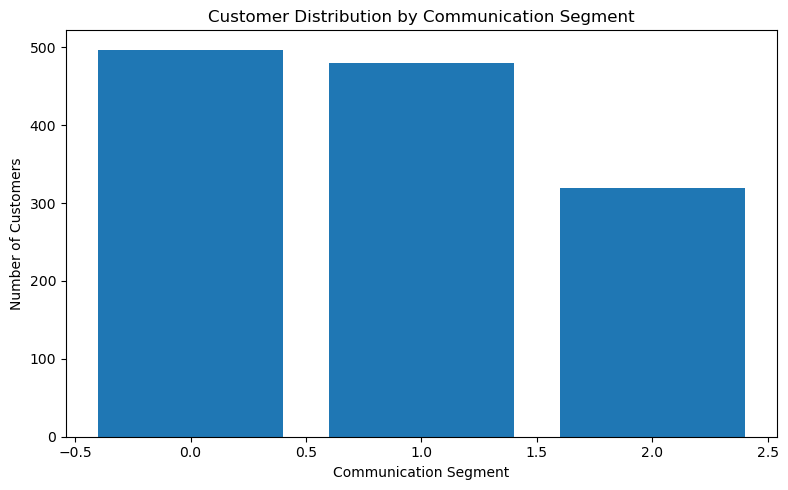

In [76]:
# Segment distribution
segment_counts = final_merged_df['Communication_Segment'].value_counts()
print(segment_counts)

plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel('Communication Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Communication Segment')
plt.tight_layout()
plt.savefig('reports/images/segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Segment Distribution:**

- **Segment 0:** 497 users (largest segment)
- **Segment 1:** 480 users
- **Segment 2:** 319 users (smallest segment)

**Analysis:**
1. **Segment 0** includes the most users — likely the most active or "typical" customer group
2. **Segment 1** is nearly as large — may represent a different but significant behavior pattern
3. **Segment 2** is smallest — could be outliers or a niche behavior group

#### Feature Analysis by Segment
Let's examine how communication features distribute across segments.

Communication_Segment
0    4.154728
1    4.291042
2    4.362696
Name: marketing_6_mon_avg, dtype: float64


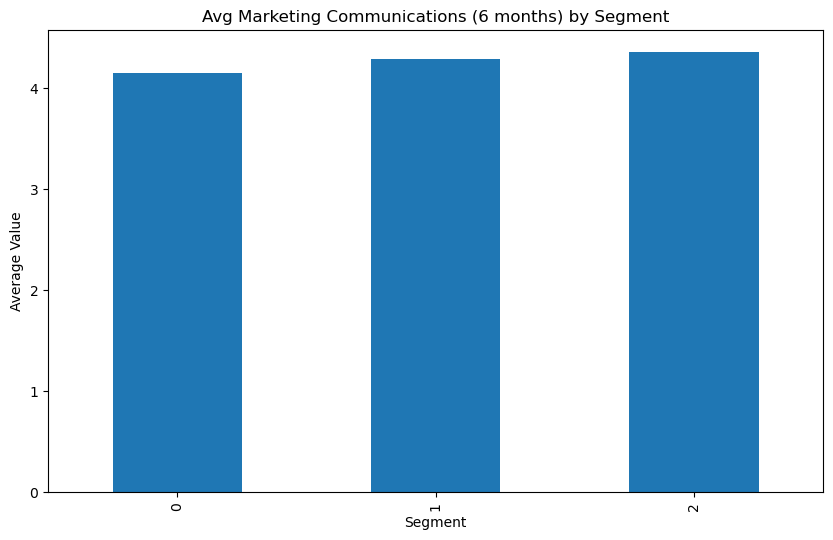

In [77]:
# Average marketing communications (6 months) by segment
marketing_6_mon_analysis = final_merged_df.groupby('Communication_Segment')['marketing_6_mon_avg'].mean()
print(marketing_6_mon_analysis)

# Visualization
marketing_6_mon_analysis.plot(kind='bar', figsize=(10, 6))
plt.title('Avg Marketing Communications (6 months) by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Value')
plt.show()

**`marketing_6_mon_avg` by Segment:**

1. **Feature Description:** Average marketing communications over 6 months

2. **Segment Distribution:**
    - **Segment 0:** Average 4.1 communications
    - **Segment 1:** Average 4.2 communications
    - **Segment 2:** Average 4.25 communications (highest)

3. **Insights:** Segment 2 receives slightly more marketing contact, yet it's the smallest segment

Communication_Segment
0    3.609658
1    3.764583
2    5.000000
Name: marketing_curr_mon, dtype: float64


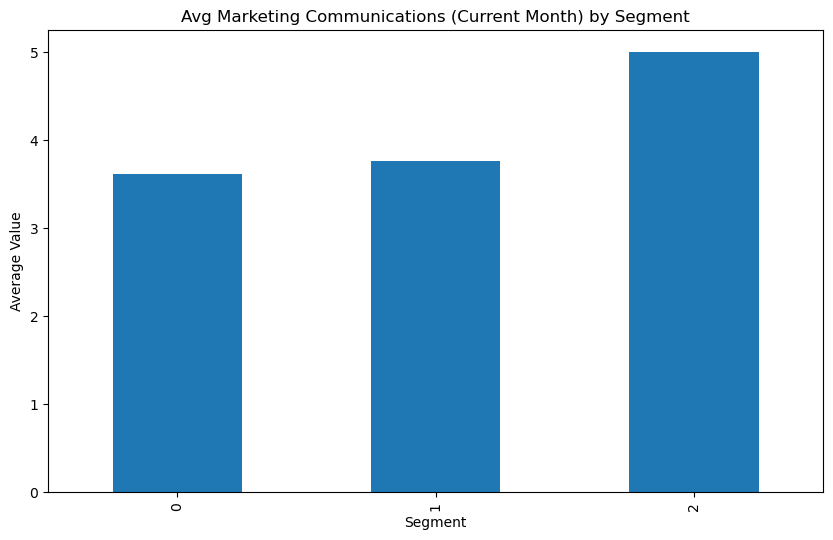

In [78]:
# Average marketing communications (current month) by segment
marketing_curr_mon_analysis = final_merged_df.groupby('Communication_Segment')['marketing_curr_mon'].mean()
print(marketing_curr_mon_analysis)

# Visualization
marketing_curr_mon_analysis.plot(kind='bar', figsize=(10, 6))
plt.title('Avg Marketing Communications (Current Month) by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Value')
plt.show()

**`marketing_curr_mon` by Segment:**

1. **Feature Description:** Marketing communications this month

2. **Segment Distribution:**
    - **Segment 0:** Lowest at 3.6
    - **Segment 1:** Slightly higher at 3.8
    - **Segment 2:** Highest at 5.0

3. **Insights:** Segment 0 has lowest current month activity — may need re-engagement

Communication_Segment
0    820.490946
1    406.333333
2    559.943574
Name: duration, dtype: float64


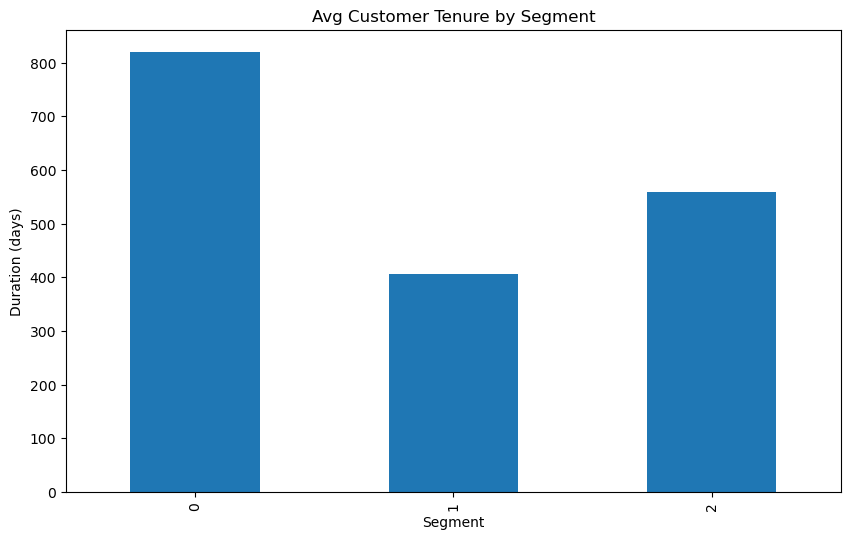

In [79]:
# Average customer duration by segment
duration_analysis = final_merged_df.groupby('Communication_Segment')['duration'].mean()
print(duration_analysis)

# Visualization
duration_analysis.plot(kind='bar', figsize=(10, 6))
plt.title('Avg Customer Tenure by Segment')
plt.xlabel('Segment')
plt.ylabel('Duration (days)')
plt.show()

**`duration` by Segment:**

1. **Feature Description:** Customer relationship duration (days)

2. **Segment Distribution:**
    - **Segment 0:** Average ~800 days (longest tenure)
    - **Segment 1:** Average ~400 days
    - **Segment 2:** Average ~580 days

3. **Insights:** Segment 0 contains the most loyal, long-term customers

#### Feature Distribution Visualization
For deeper analysis, let's build box plots for each feature by segment.

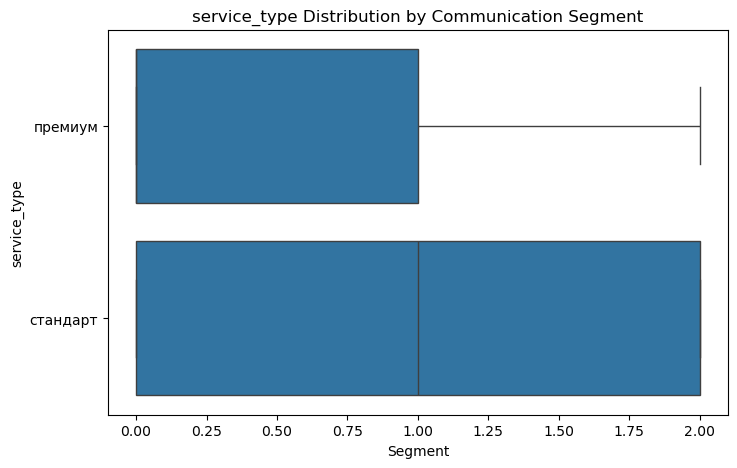

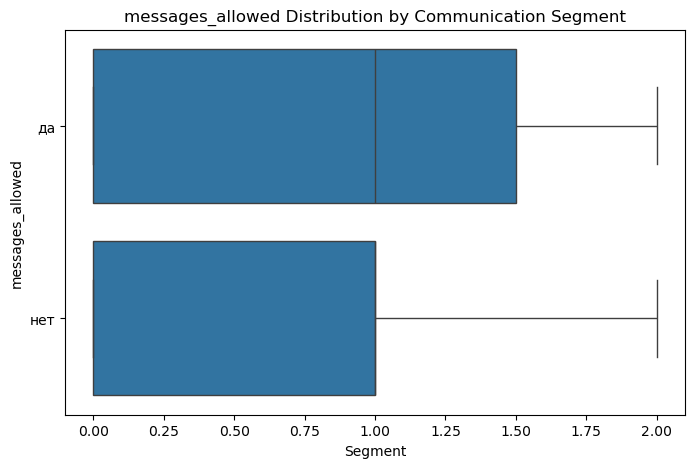

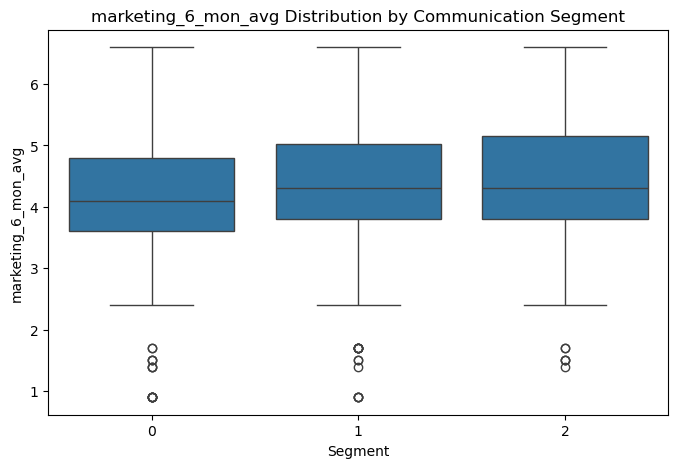

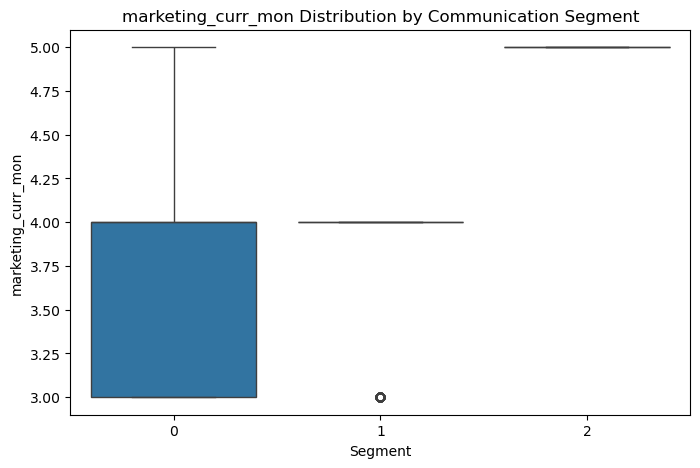

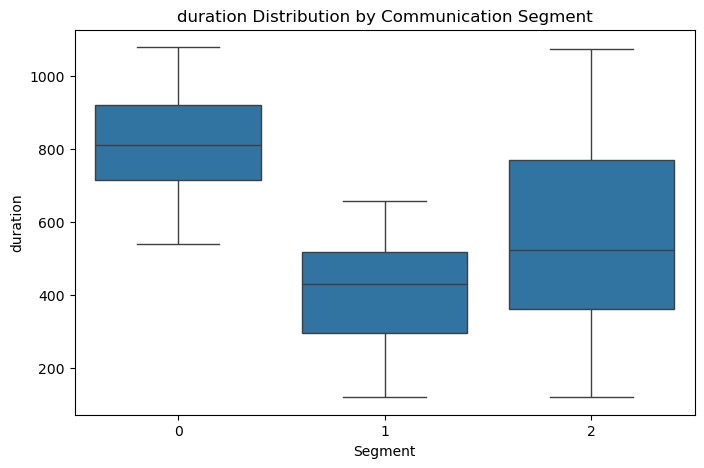

In [80]:
# Boxplots for communication features by segment
for feature in communication_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Communication_Segment', y=feature, data=final_merged_df)
    plt.title(f'{feature} Distribution by Communication Segment')
    plt.xlabel('Segment')
    plt.ylabel(feature)
    plt.show()

**Box Plot Insights:**

1. **`service_type`:** Segment 0 primarily consists of premium users; Segments 1 and 2 have more standard users
2. **`messages_allowed`:** Segments 0 and 2 more often allow messages vs. Segment 1
3. This suggests different engagement levels and communication preferences per segment

#### Segment Activity Analysis
Let's analyze how segments differ by target variable.

buying_activity        прежний уровень  снизилась
Communication_Segment                            
0                             0.583501   0.416499
1                             0.660417   0.339583
2                             0.611285   0.388715


<Figure size 1000x600 with 0 Axes>

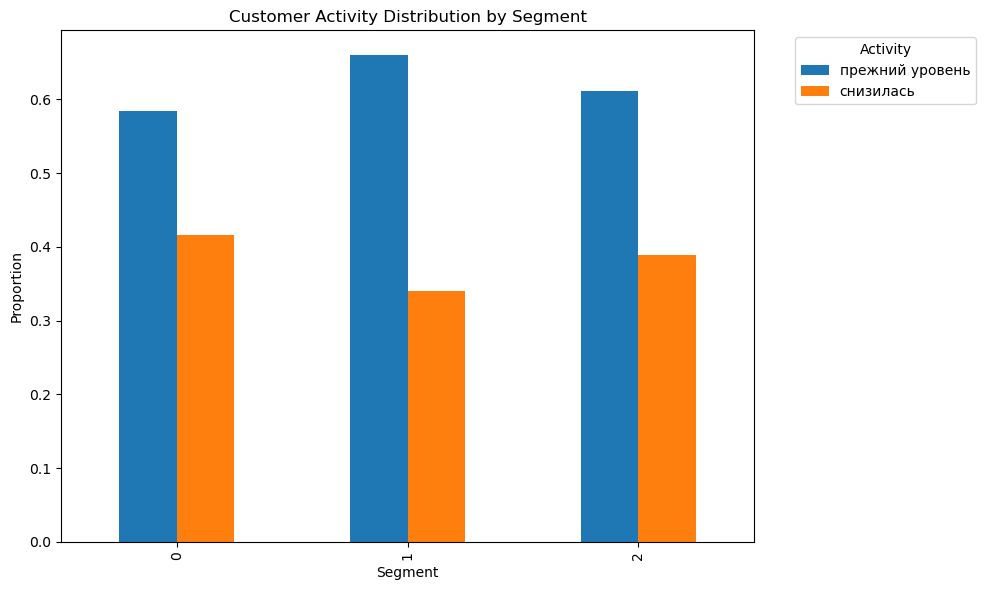

In [81]:
# Activity distribution by segment
activity_distribution = final_merged_df.groupby('Communication_Segment')['buying_activity'].value_counts(normalize=True).unstack()
print(activity_distribution)

# Visualization
plt.figure(figsize=(10, 6))
activity_distribution.plot(kind='bar', figsize=(10, 6))
plt.title('Customer Activity Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Proportion')
plt.legend(title='Activity', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('reports/images/segment_activity.png', dpi=150, bbox_inches='tight')
plt.show()

**Activity Distribution by Segment:**

**Segment 0:**
- **Stable activity:** ~58%
- **Declined activity:** ~42%
- Highest churn risk — priority segment for retention

**Segment 1:**
- **Stable activity:** ~66%
- **Declined activity:** ~34%
- Best retention rate among segments

**Segment 2:**
- **Stable activity:** ~61%
- **Declined activity:** ~39%
- Second highest churn risk — also needs attention

### Segmentation Conclusions

**Key Findings:**

1. Customers naturally cluster into three distinct segments with unique activity patterns
2. Significant activity decline observed in multiple segments, especially Segment 0 (42%) and Segment 2 (39%)
3. Retention strategies should prioritize segments with highest decline rates

**Recommendations for the Business:**

| Segment | Profile | Priority | Strategy |
|---------|---------|----------|----------|
| 0 | Premium, long-tenure, 42% churning | **HIGH** | Loyalty programs, exclusive offers |
| 1 | Standard, mid-tenure, 34% churning | Medium | Maintain engagement |
| 2 | Mixed, shorter-tenure, 39% churning | **HIGH** | Targeted re-engagement |

## Executive Summary

**Project Objective:**
Develop a personalized engagement solution for an e-commerce store to retain customer activity and increase profitability.

---

### Research Stages:

1. **Data Preprocessing:**
    - Cleaned, transformed, and merged data from multiple sources
    - Handled missing values and standardized formats

2. **Exploratory Data Analysis (EDA):**
    - Identified key patterns in customer behavior
    - Discovered significant differences between active and declining customers

3. **Model Development:**
    - Tested 4 classification models: KNN, Decision Tree, Logistic Regression, SVC
    - **Best Model: SVC with F1 = 0.91** (90% improvement over baseline)

4. **Feature Importance (SHAP):**
    - Top predictors: pages viewed per session, time on site, marketing communications

5. **Customer Segmentation:**
    - K-Means clustering identified 3 distinct customer segments
    - Segment 0 (premium, long-term) requires immediate attention

---

### Business Impact:

- **Prediction Accuracy:** 91% F1 score enables reliable activity forecasting
- **Actionable Segments:** Clear targeting for retention campaigns
- **ROI Potential:** Focus on high-value at-risk customers (Segment 0)

### Next Steps:

1. Deploy SVC model for real-time activity prediction
2. Implement segment-specific retention campaigns
3. Monitor and retrain model quarterly